In [1]:
%reset -f 

from LadrunoGraphStyle import set_default_plot_params, main_colors
set_default_plot_params()

In [2]:
from ShakerMakerResults import ShakerMakerData
from ShakerMakerResults import StationData

import numpy as np
import os

## DRM

In [3]:
# folder= '/home/pxpalacios/Dropbox/01. Brain/10. Ph.D U ANDES/04. Clases/02. Semestre02 2025-2/01. SAIC/00_test_shakermaker/03_all_functions_OP/03_DRM_HalfSpace_PXP/01_DRM/'
folder = r'C:\Dropbox\01. Brain\10. Ph.D U ANDES\04. Clases\02. Semestre02 2025-2\01. SAIC\00_test_shakermaker\03_all_functions_OP\03_DRM_HalfSpace_PXP\01_DRM'
h5drm = os.path.join(folder, 'DRM_10m.h5drm')
h5gf  = os.path.join(folder, 'gf_database_10m.h5')


drm_gaussian = ShakerMakerData(h5drm)
drm_gaussian.load_gf_database(h5gf)


----------------------------------------------------------------------------------------------------
ShakerMakerData  :  C:\Dropbox\01. Brain\10. Ph.D U ANDES\04. Clases\02. Semestre02 2025-2\01. SAIC\00_test_shakermaker\03_all_functions_OP\03_DRM_HalfSpace_PXP\01_DRM\DRM_10m.h5drm
  Type     : DRM
  Model    : 10.0m  |  Spacing: 10.0m x 10.0m x 10.0m
  Nodes    : 426  |  Internal: 161  |  External: 265
  QA       : yes  ->  [6000. 8000.    0.] m
  Time     : dt=0.005s  |  steps=20000  |  t=[0.000, 100.000]s
  GF       : steps=0  |  not loaded
  Version  : ShakeMaker version 1.1  |  17-Mar-2026 (10:09:34.225081)
----------------------------------------------------------------------------------------------------

Loading GF database: C:\Dropbox\01. Brain\10. Ph.D U ANDES\04. Clases\02. Semestre02 2025-2\01. SAIC\00_test_shakermaker\03_all_functions_OP\03_DRM_HalfSpace_PXP\01_DRM\gf_database_10m.h5
  GF DB (O(1) pair_to_slot): 425 slots  |  425/426 computed (0.2% reduction)
Done.


In [4]:
# get_window

drm_gaussian_window= drm_gaussian.get_window(t_start=0.0, t_end=15.0)

Window [0.0, 15.0]s → 3001 samples


----------------------------------------------------------------------------------------------------
Resample
  dt       :  0.005s  →  0.01s
  Steps    :  20000  →  10000
  Duration :  0.000s  —  99.995s  (unchanged)
----------------------------------------------------------------------------------------------------

--------------------------------------------------
NODE INFO
  QA       │ pos = [   6000.00,    8000.00,       0.00] m
--------------------------------------------------


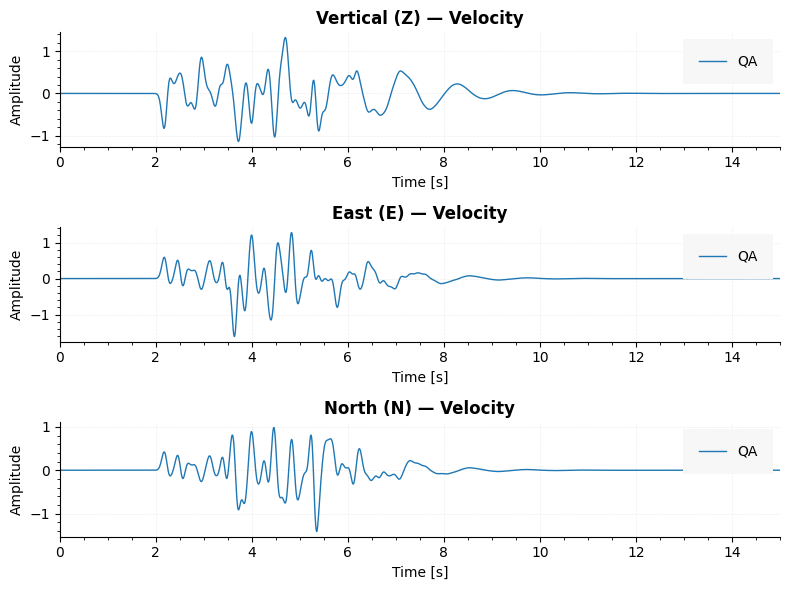

In [5]:
# resample 

resample_drm_gaussian = drm_gaussian.resample(dt=0.01)
resample_drm_gaussian.plot_node_response(
                                node_id='QA', 
                                # target_pos=[6,8,0],
                                data_type='vel', 
                                figsize=(8, 6),
                                factor=1.0,
                                xlim=[0, 15])

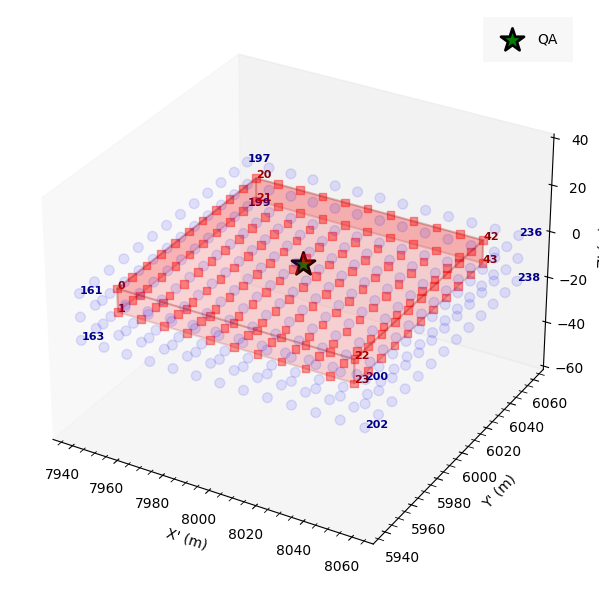

QA position: [8000. 6000.    0.]


(<Figure size 800x600 with 1 Axes>,
 <Axes3D: xlabel="X' (m)", ylabel="Y' (m)", zlabel="Z' (m)">)

In [6]:
drm_gaussian_window.plot_domain(   xyz_origin=None, 
                            label_nodes='corners',
                            show_calculated=False,
                            axis_equal=True)

----------------------------------------------------------------------------------------------------
GF NODE CLASSIFICATION
  Super Donors    (2)  :  [87, 324]
  Solitary Donors (423)  :  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 

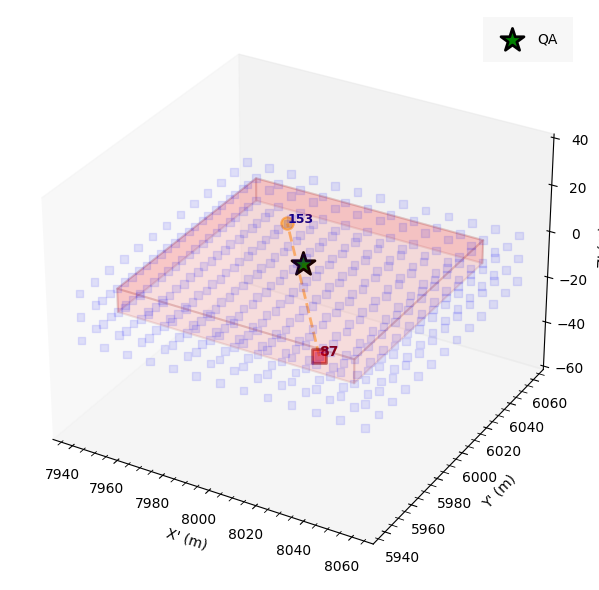

In [7]:
drm_gaussian_window.plot_gf_connections(
                        node_id=87,
                        xyz_origin=None,
                        label_nodes='donor_receivers',
                        figsize=(8,6),
                        axis_equal=True)  

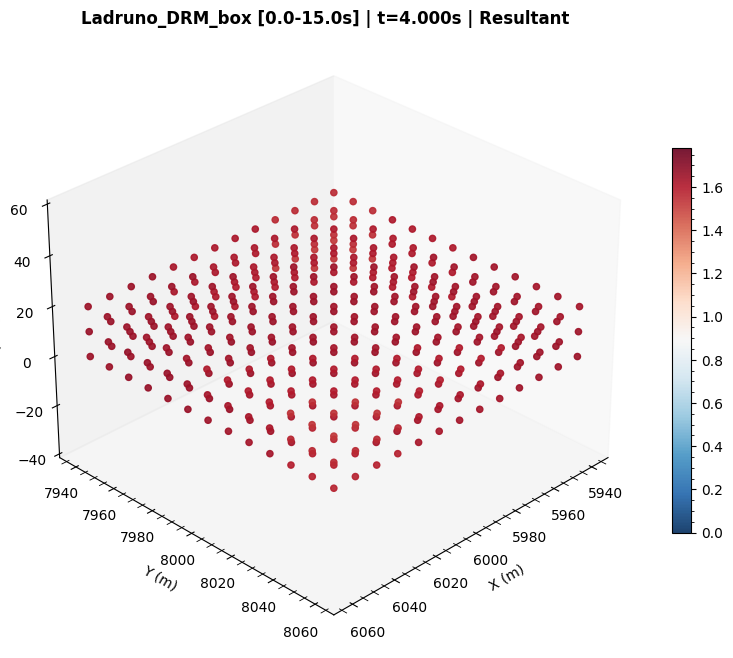

In [8]:
# Plot surface snapshot
drm_gaussian_window.plot_surface(  time=4.0, 
                            component='resultant', 
                            data_type='vel', 
                            cmap='RdBu_r', 
                            figsize=(8, 8),
                            elev=30, azim=45, s=20, alpha=0.9,
                            axis_equal=True,)
    

--------------------------------------------------
NODE INFO
  N163    │ pos = [   5940.00,    7940.00,      20.00] m │ external
  N236    │ pos = [   6060.00,    8060.00,       0.00] m │ external
--------------------------------------------------


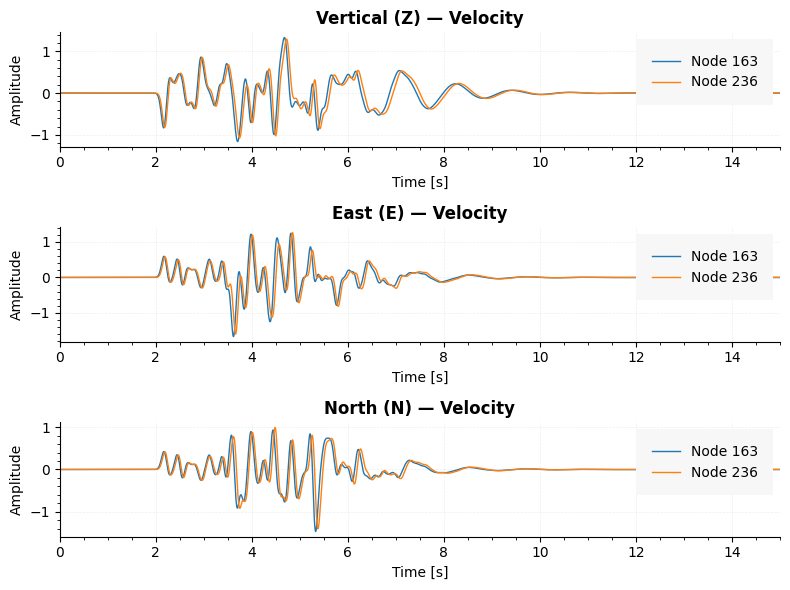

In [9]:
# Por ID
drm_gaussian_window.plot_node_response( 
                        node_id=[163,236], 
                        # target_pos=[6,8,0],
                        data_type='vel', 
                        figsize=(8, 6),
                        factor=1.0,
                        xlim=[0, 15]
                        )

--------------------------------------------------
NODE INFO
  N163    │ pos = [   5940.00,    7940.00,      20.00] m │ external
  N236    │ pos = [   6060.00,    8060.00,       0.00] m │ external
--------------------------------------------------


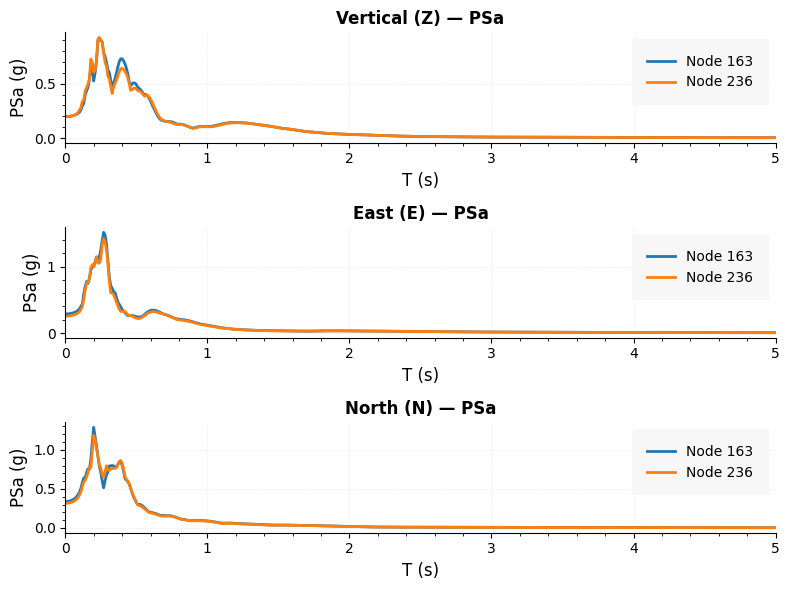

In [10]:
# Por ID
drm_gaussian_window.plot_node_newmark( 
                        node_id=[163,236], 
                        # target_pos=[6,8,0],
                        data_type='accel', 
                        spectral_type='PSa',
                        figsize=(8, 6),
                        factor=9.81,
                        # xlim=[0, 5]
                        )

--------------------------------------------------
NODE INFO
  N163    │ pos = [   5940.00,    7940.00,      20.00] m │ external
  N236    │ pos = [   6060.00,    8060.00,       0.00] m │ external
--------------------------------------------------


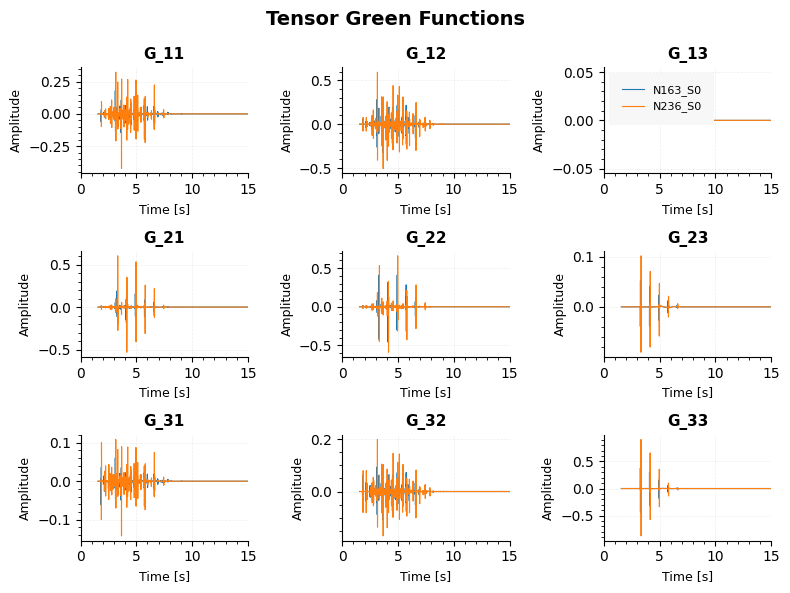

In [11]:
drm_gaussian_window.plot_node_tensor_gf(
                        node_id=[163,236], 
                        # target_pos=[6,8,0],
                        subfault=0, 
                        figsize=(8, 6),
                        xlim=[0, 15])

--------------------------------------------------
NODE INFO
  QA       │ pos = [   6000.00,    8000.00,       0.00] m
--------------------------------------------------


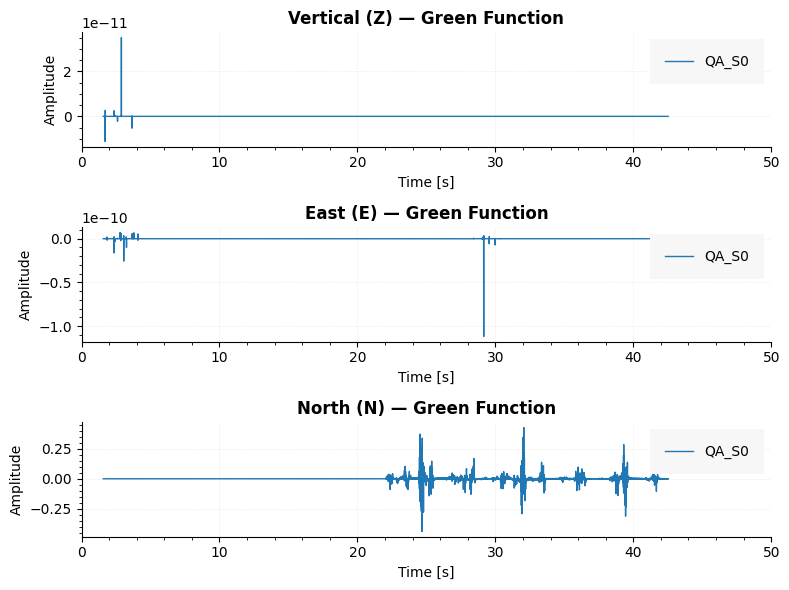

In [12]:
drm_gaussian_window.plot_node_gf(              
                    node_id=['QA'], 
                    # target_pos=[6,8,0],
                    subfault=0, 
                    figsize=(8, 6),
                    xlim=[0, 50]
                    )

## FilledBox

In [13]:
# folder= '/home/pxpalacios/Dropbox/01. Brain/10. Ph.D U ANDES/04. Clases/02. Semestre02 2025-2/01. SAIC/00_test_shakermaker/03_all_functions_OP/03_DRM_HalfSpace_PXP/01_FilledBox/'
folder = r'C:\Dropbox\01. Brain\10. Ph.D U ANDES\04. Clases\02. Semestre02 2025-2\01. SAIC\00_test_shakermaker\03_all_functions_OP\03_DRM_HalfSpace_PXP\01_FilledBox'
h5drm = os.path.join(folder, 'Surface_10m.h5drm')
h5gf  = os.path.join(folder, 'gf_database_10m.h5')


FilledBox_gaussian = ShakerMakerData(h5drm)
FilledBox_gaussian.load_gf_database(h5gf)


----------------------------------------------------------------------------------------------------
ShakerMakerData  :  C:\Dropbox\01. Brain\10. Ph.D U ANDES\04. Clases\02. Semestre02 2025-2\01. SAIC\00_test_shakermaker\03_all_functions_OP\03_DRM_HalfSpace_PXP\01_FilledBox\Surface_10m.h5drm
  Type     : SurfaceGrid
  Model    : 10.0m  |  Spacing: 10.0m x 10.0m x 10.0m
  Nodes    : 242  |  Internal: 0  |  External: 242
  QA       : yes  ->  [6000. 8000.    0.] m
  Time     : dt=0.005s  |  steps=20000  |  t=[0.000, 100.000]s
  GF       : steps=0  |  not loaded
  Version  : ShakeMaker version 1.1  |  17-Mar-2026 (12:15:30.960914)
----------------------------------------------------------------------------------------------------

Loading GF database: C:\Dropbox\01. Brain\10. Ph.D U ANDES\04. Clases\02. Semestre02 2025-2\01. SAIC\00_test_shakermaker\03_all_functions_OP\03_DRM_HalfSpace_PXP\01_FilledBox\gf_database_10m.h5
  GF DB (O(1) pair_to_slot): 240 slots  |  240/242 computed (0.8% re

In [14]:
# get_window

FilledBox_gaussian_window= FilledBox_gaussian.get_window(t_start=0.0, t_end=15.0)


Window [0.0, 15.0]s → 3001 samples


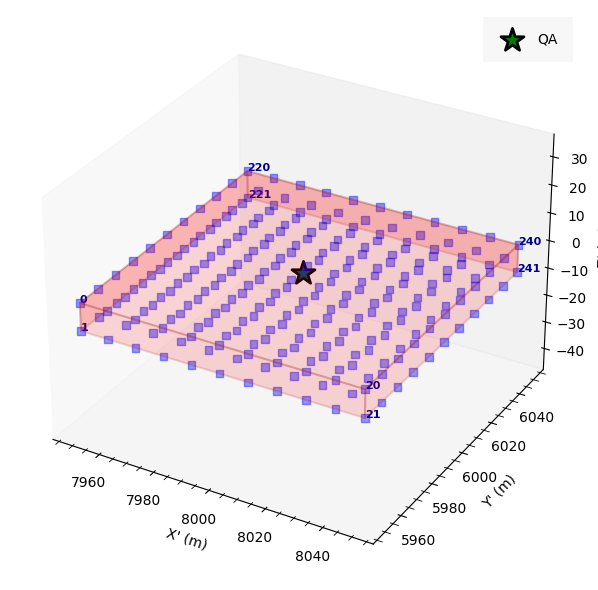

QA position: [8000. 6000.    0.]


(<Figure size 800x600 with 1 Axes>,
 <Axes3D: xlabel="X' (m)", ylabel="Y' (m)", zlabel="Z' (m)">)

In [15]:
FilledBox_gaussian_window.plot_domain(   xyz_origin=None, 
                            label_nodes='corners',
                            show_calculated=False,
                            axis_equal=True)

In [16]:
# # create_animation 3D
# ffmpeg_exe = r'C:\Dropbox\01. Brain\10. Ph.D U ANDES\21. ffmpeg\ffmpeg-2025-09-18-git-c373636f55-essentials_build\bin\ffmpeg.exe'

# FilledBox_gaussian.create_animation(
#     time_start  = 0,
#     time_end    = 15,  
#     n_frames    = 100,
#     component   = 'z',
#     data_type   = 'vel',
#     cmap        = 'RdBu_r',
#     figsize     = (10, 8),
#     dpi         = 100,
#     fps         = 5,
#     elev        = 35, azim = 45,
#     s           = 20, alpha = 0.85,
#     output_dir  = './anim_full',
#     output_video= './anim_full.mp4',
#     ffmpeg_path=ffmpeg_exe,
#     axis_equal=True,
# )

# # reate_animation plane

# FilledBox_gaussian.create_animation_plane(
#     plane='xy',
#     plane_value=0,
#     time_start  = 0,
#     time_end    = 15,  
#     n_frames    = 100,
#     component   = 'z',
#     data_type   = 'vel',
#     cmap        = 'RdBu_r',
#     figsize     = (10, 8),
#     dpi         = 100,
#     fps         = 5,
#     elev        = 35, azim = 45,
#     s           = 50, alpha = 0.85,
#     output_dir  = './anim_full_xy',
#     output_video= './anim_full_xy.mp4',
#     ffmpeg_path=ffmpeg_exe,
# )

## Surface


In [17]:
# folder= '/home/pxpalacios/Dropbox/01. Brain/10. Ph.D U ANDES/04. Clases/02. Semestre02 2025-2/01. SAIC/00_test_shakermaker/03_all_functions_OP/03_DRM_HalfSpace_PXP/01_Surface/'
folder = r'C:\Dropbox\01. Brain\10. Ph.D U ANDES\04. Clases\02. Semestre02 2025-2\01. SAIC\00_test_shakermaker\03_all_functions_OP\03_DRM_HalfSpace_PXP\01_Surface'
h5drm = os.path.join(folder, 'Surface_10m.h5drm')
h5gf  = os.path.join(folder, 'gf_database_10m.h5')


surface_gaussian = ShakerMakerData(h5drm)
surface_gaussian.load_gf_database(h5gf)


----------------------------------------------------------------------------------------------------
ShakerMakerData  :  C:\Dropbox\01. Brain\10. Ph.D U ANDES\04. Clases\02. Semestre02 2025-2\01. SAIC\00_test_shakermaker\03_all_functions_OP\03_DRM_HalfSpace_PXP\01_Surface\Surface_10m.h5drm
  Type     : SurfaceGrid
  Model    : 10.0m  |  Spacing: 10.0m x 10.0m x 0.0m
  Nodes    : 121  |  Internal: 0  |  External: 121
  QA       : yes  ->  [6000. 8000.    0.] m
  Time     : dt=0.005s  |  steps=20000  |  t=[0.000, 100.000]s
  GF       : steps=0  |  not loaded
  Version  : ShakeMaker version 1.1  |  17-Mar-2026 (14:40:00.153962)
----------------------------------------------------------------------------------------------------

Loading GF database: C:\Dropbox\01. Brain\10. Ph.D U ANDES\04. Clases\02. Semestre02 2025-2\01. SAIC\00_test_shakermaker\03_all_functions_OP\03_DRM_HalfSpace_PXP\01_Surface\gf_database_10m.h5
  GF DB (O(1) pair_to_slot): 120 slots  |  120/121 computed (0.8% reducti

In [18]:
# get_window

surface_gaussian_window= surface_gaussian.get_window(t_start=0.0, t_end=15.0)

Window [0.0, 15.0]s → 3001 samples


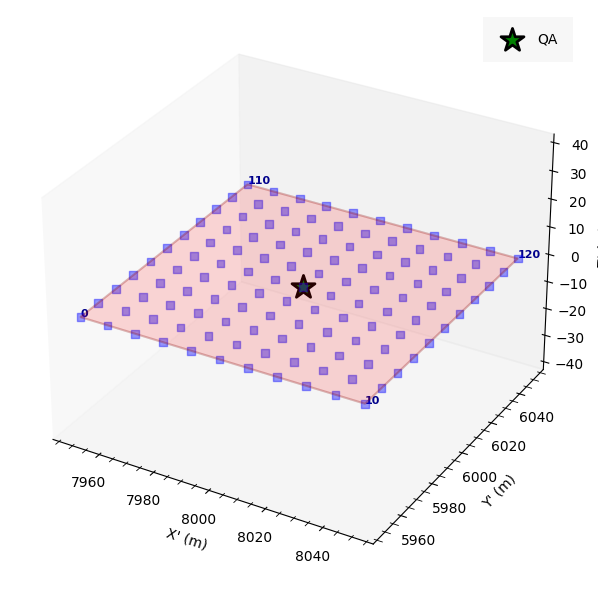

QA position: [8000. 6000.    0.]


(<Figure size 800x600 with 1 Axes>,
 <Axes3D: xlabel="X' (m)", ylabel="Y' (m)", zlabel="Z' (m)">)

In [19]:
surface_gaussian_window.plot_domain(   xyz_origin=None, 
                            label_nodes='corners',
                            show_calculated=False,
                            axis_equal=True)

----------------------------------------------------------------------------------------------------
GF NODE CLASSIFICATION
  Super Donors    (2)  :  [19, 60]
  Solitary Donors (118)  :  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]
  Pure Receivers  (2)  :  [101, 121]
----------------------------------------------------------------------------------------------------
  Analyzing Node : 101
----------------------------------------------------------------------------------------------------
  Node 101  →  RECEIVER  ←  donor 19
-------------------------------

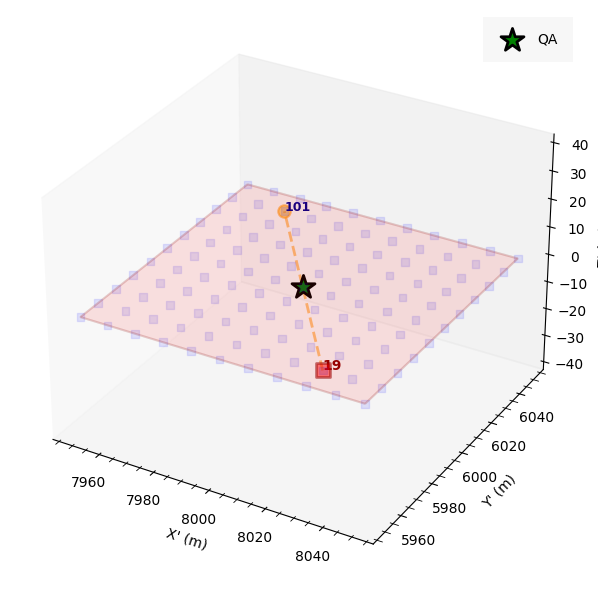

In [20]:
surface_gaussian_window.plot_gf_connections(
                        node_id=101,
                        xyz_origin=None,
                        label_nodes='donor_receivers',
                        figsize=(8,6),
                        axis_equal=True)  

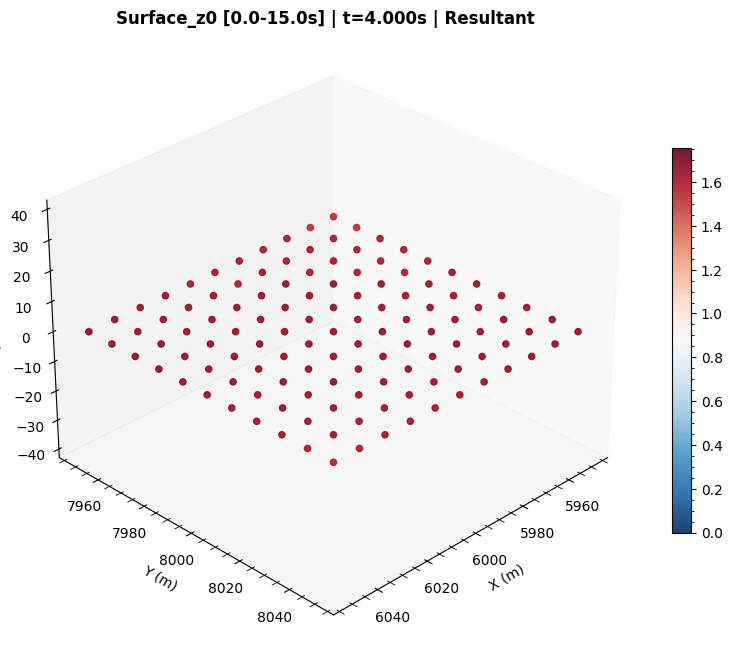

In [21]:
# Plot surface snapshot
surface_gaussian_window.plot_surface(  time=4.0, 
                            component='resultant', 
                            data_type='vel', 
                            cmap='RdBu_r', 
                            figsize=(8, 8),
                            elev=30, azim=45, s=20, alpha=0.9,
                            axis_equal=True,)
    